In [14]:
from Bio import AlignIO
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# Load the dataset 
msa_path = "D:/Genome Analysis/BRCA1 Analysis Project/BRCA1_alignment.aln-clustal_num"

alignment = AlignIO.read(msa_path, "clustal")

print("Number of Sequences in MSA: ", len(alignment))
print("Alignment length (columns): ", alignment.get_alignment_length() )

Number of Sequences in MSA:  10
Alignment length (columns):  7315


## print each sequences from alignment

In [16]:
records = []

for record in alignment:
    records.append([record.id.split(".")[0], str(record.seq)])

print("Total Sequences: ", len(records))
print(records)

Total Sequences:  10
[['NM_001407726', '---------------------------------------------------------------------------------------------------------------------------------------------------------GCTGAGACTTCCTGGACGGGGGACAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGCGCTCAGGAGGCCTTCACCCTCTGCTCTGG------TTCATTGGAACAGAAAGAAATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTATGCAGAAAATCTTAGAGTGTCCCATCTGACTTTGGCTCTTGTTGCCCAGGCTGGAGTGCAGTGGCACAATCTCGGCTCACTACAACCTCCACCTCCCGGGTTCAAGCAATTCTGCTGCCTCAGCCTCCGGAGTACCTGGGATTGCAGATTTTGCATGCTGAAACTTCTCAACCAGAAGAAAGGGCCTTCACAGTGTCCTTTATGTAAGAATGATATAACCAAAAGGAGCCTACAAGAAAGTACGAGATTTAGTCAACTTGTTGAAGAGCTATTGAAAATCATTTGTGCTTTTCAGCTTGACACAGGTTTGGAGTATGCAAACAGCTATAATTTTGCAAAAAAGGAAAATAACTCTCCTGAACATCTAAAAGATGAAGTTTCTATCATCCAAAGTATGGGCTACAGAAACCGTGCCAAAAGACTTCTACAGAGTGAACCCGAAAATCCTTCCTTGCAGGAAACCAGTCTCAGTGTCCAACTCTCTAACCTTGGAACTGTGAGAACTCTGAGGACAAAGCAGCGGATACAACCTCAAAAGACGTCTGTCTACATTGAATTGGGATCTGATTCTTCTGAAGATACCGTTAATAAGGCAACTTATTGCAGTGTGGGAGATCAAGAATTGTTACAAATCACCCCTCA

## Calculate column-wise conservation 

In [17]:
from collections import Counter

In [18]:
alignment_length = alignment.get_alignment_length()
print(alignment_length)

num_sequences = len(alignment)
print(num_sequences)

7315
10


In [19]:
conservation_scores = []

for col in range(alignment_length):
    column = alignment[:, col]
    counts = Counter(column)

    # ignore gaps
    if '-' in counts:
        del counts['-']

    if len(counts) == 0:
        conservation_scores.append(0)
    else:
        # frequency of most common nucleotide at this column
        most_common_count = counts.most_common(1)[0][1]
        conservation_scores.append(most_common_count/num_sequences)

print("Conservation scores calculated for", alignment_length, "positions.")
print(conservation_scores)

Conservation scores calculated for 7315 positions.
[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.3, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0

## Plot Conservation

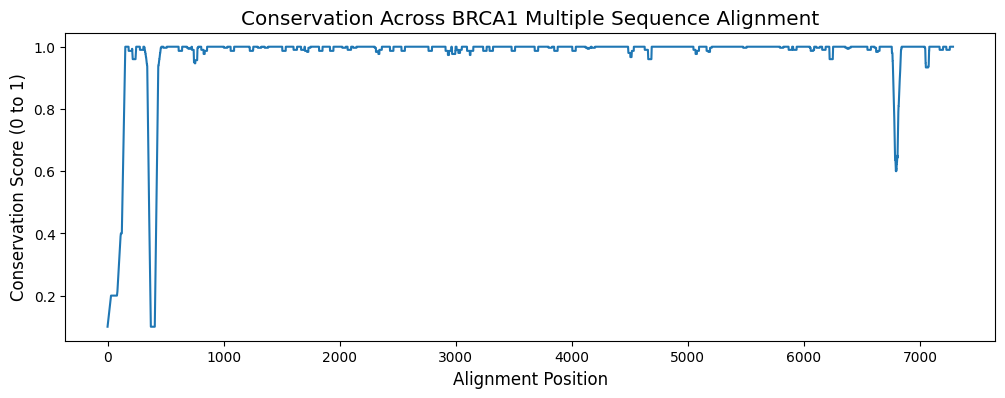

In [20]:
window = 30 
smoothed_scores = np.convolve(conservation_scores, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,4))
plt.plot(smoothed_scores)
plt.xlabel("Alignment Position")
plt.ylabel("Conservation Score (0 to 1)")
plt.title("Conservation Across BRCA1 Multiple Sequence Alignment")
plt.savefig("conservation_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Convert .aln to .phy

In [21]:
# save in phylip format
AlignIO.write(alignment, "BRCA1_alignment.phy", "phylip-relaxed")

1

In [22]:
from Bio.Phylo.TreeConstruction import DistanceCalculator

phy_alignment = AlignIO.read("BRCA1_alignment.phy", "phylip-relaxed")
calculator = DistanceCalculator("identity")
distance_matrix = calculator.get_distance(phy_alignment)

print(distance_matrix)

NM_001407726.1  0.000000
XM_054669718.2  0.030212    0.000000
NM_001407637.1  0.017635    0.016131    0.000000
NM_001407611.1  0.017225    0.016541    0.000410    0.000000
NM_001407616.1  0.017225    0.016541    0.000410    0.000820    0.000000
NM_007294.4 0.016815    0.016951    0.000820    0.000410    0.000410    0.000000
NM_001407624.1  0.017225    0.016541    0.001230    0.000820    0.000820    0.000410    0.000000
XM_031011552.3  0.048530    0.028708    0.034586    0.034176    0.034176    0.033766    0.034176    0.000000
XM_054669709.2  0.044976    0.018045    0.030212    0.030622    0.029802    0.030212    0.030622    0.014491    0.000000
XM_054669710.2  0.033356    0.007519    0.018592    0.018182    0.019002    0.018592    0.019002    0.026111    0.012440    0.000000
    NM_001407726.1  XM_054669718.2  NM_001407637.1  NM_001407611.1  NM_001407616.1  NM_007294.4 NM_001407624.1  XM_031011552.3  XM_054669709.2  XM_054669710.2


## Construct the phylogenetic tree

In [23]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor

constructor = DistanceTreeConstructor()
nj_tree = constructor.nj(distance_matrix)
print(nj_tree)

Tree(rooted=False)
    Clade(branch_length=0, name='Inner8')
        Clade(branch_length=0.0011705399863294746, name='Inner4')
            Clade(branch_length=0.015680109364319916, name='NM_001407726.1')
            Clade(branch_length=0.011729323308270648, name='Inner3')
                Clade(branch_length=0.002620186830713151, name='Inner2')
                    Clade(branch_length=0.002704813983009478, name='XM_054669710.2')
                    Clade(branch_length=0.009325261204960468, name='Inner1')
                        Clade(branch_length=0.00428913192071087, name='XM_054669709.2')
                        Clade(branch_length=0.01020164046479835, name='XM_031011552.3')
                Clade(branch_length=0.003189792663476892, name='XM_054669718.2')
        Clade(branch_length=7.68967874231058e-05, name='Inner7')
            Clade(branch_length=0.00023069036226928963, name='NM_001407611.1')
            Clade(branch_length=0.00017942583732057094, name='Inner5')
                Clad

## Visualize the tree

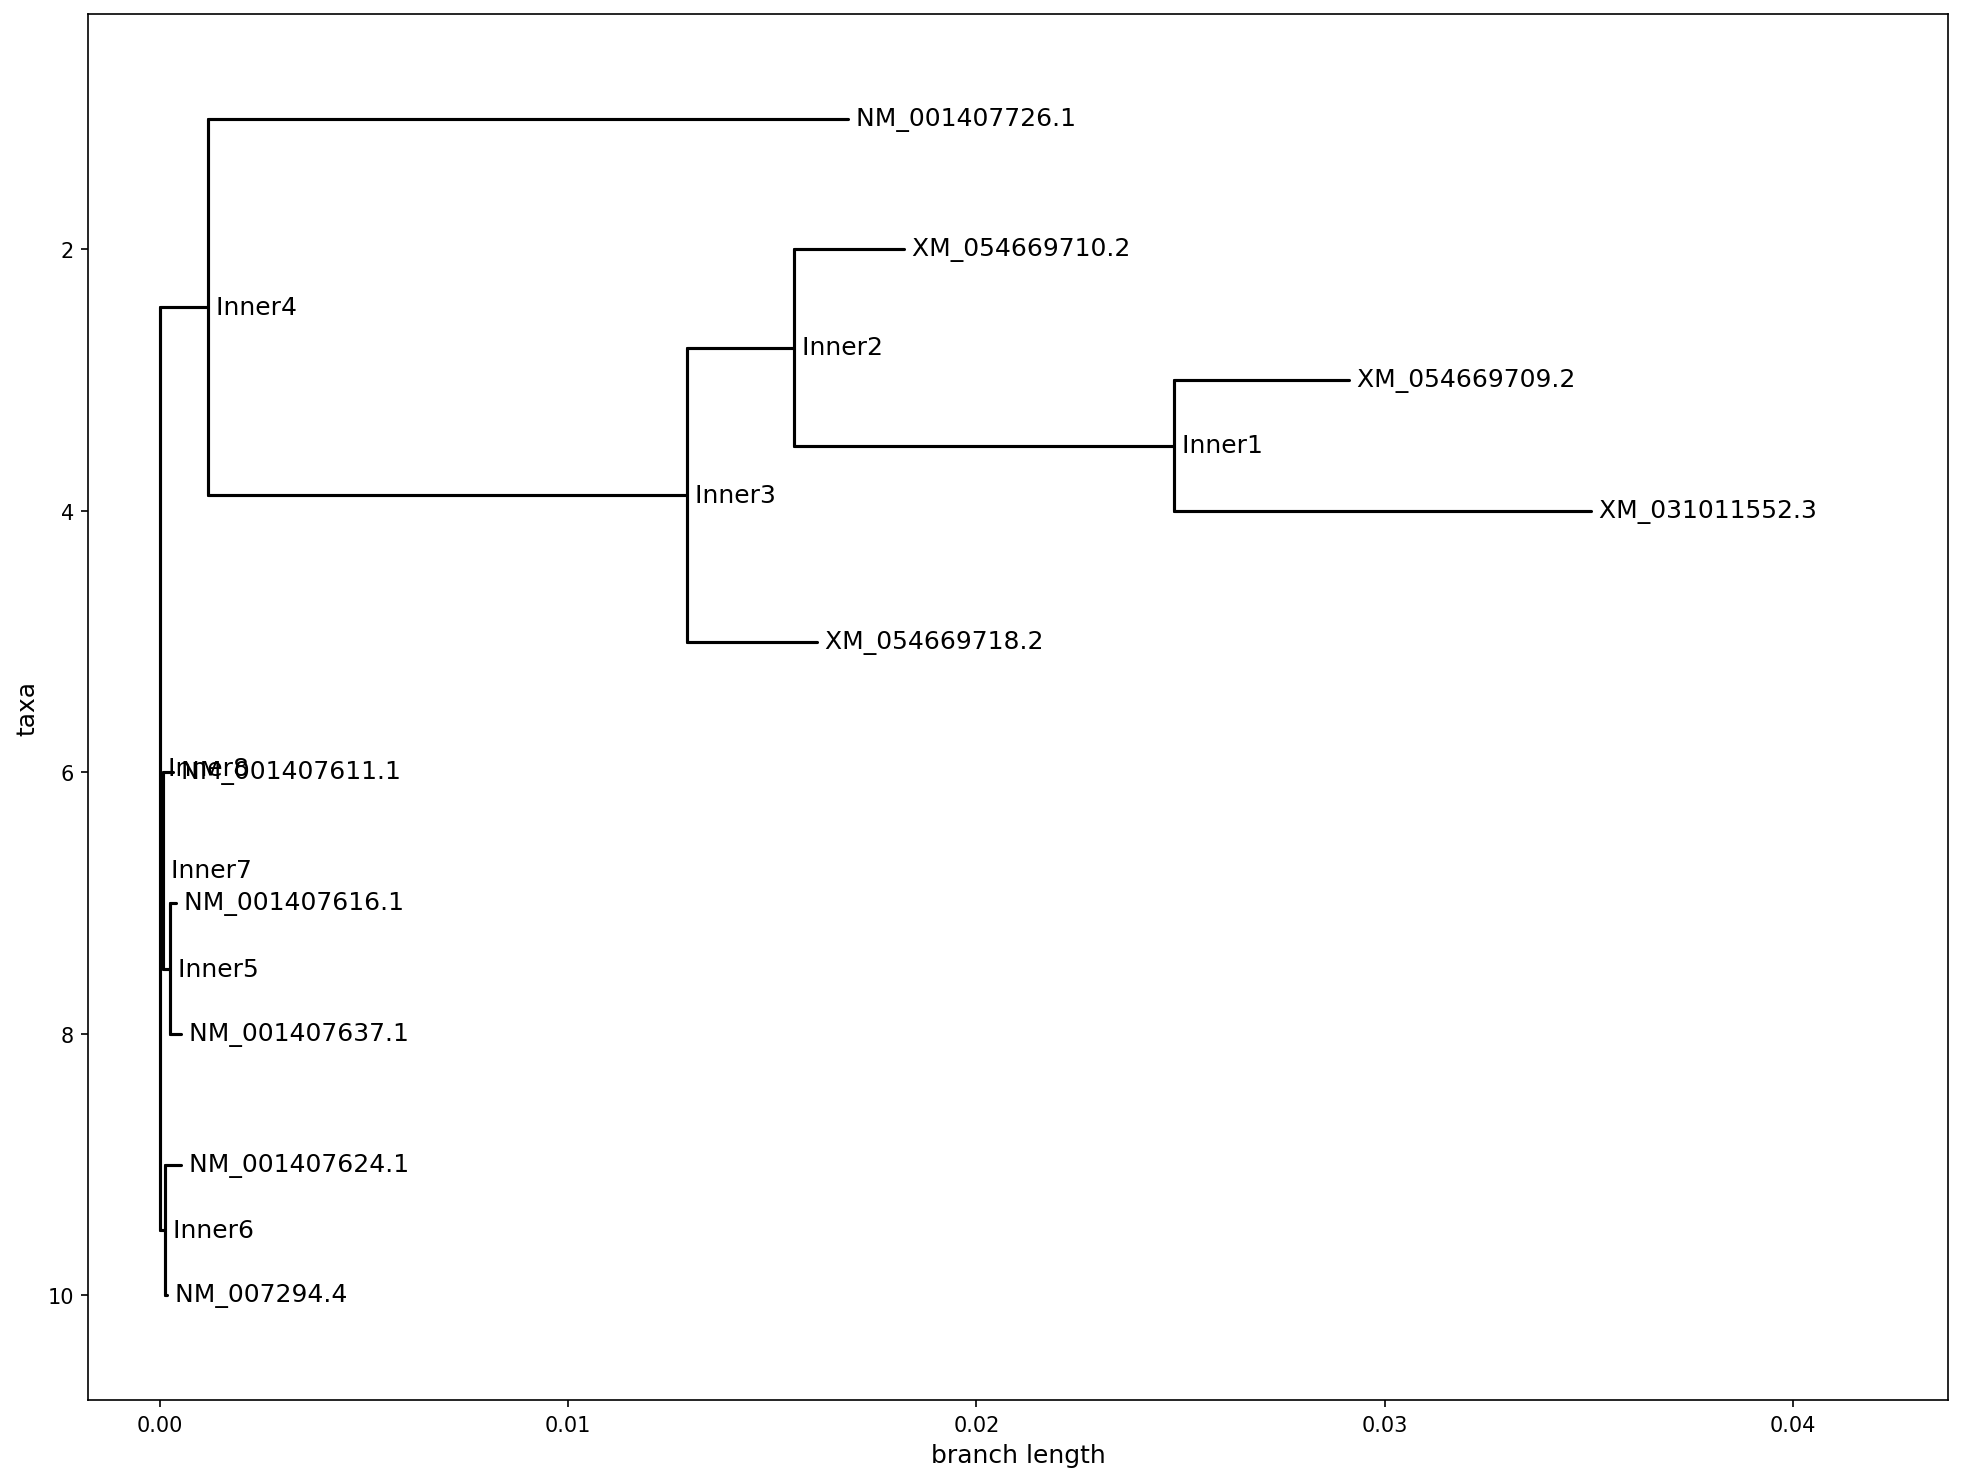

<Figure size 640x480 with 0 Axes>

In [24]:
from Bio import Phylo
fig = plt.figure(figsize=(16,12), dpi=150)
matplotlib.rc('font', size=12)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
axes = fig.add_subplot(1,1,1)
Phylo.draw(nj_tree, axes=axes)
plt.savefig("phylogenetic_tree.png", dpi=300, bbox_inches="tight")
plt.show()